<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Desafio 2 PLN CEIA Ojeda, Juan
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

### Desafio para el alumno

- Crear sus propios vectores con Gensim basado en lo visto en clase con otro dataset.
- Probar términos de interés y explicar similitudes en el espacio de embeddings (sacar conclusiones entre palabras similitudes y diferencias).
- Graficarlos.
- Obtener conclusiones.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
from gensim.models import Word2Vec  
from sklearn.manifold import TSNE                   
import numpy as np
from tensorflow.keras.preprocessing.text import text_to_word_sequence # type: ignore


### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [28]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    with zipfile.ZipFile("songs_dataset.zip", 'r') as zip_ref:
        zip_ref.extractall(".")   
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [3]:
# Posibles bandas
os.listdir("./songs_dataset")

['adele.txt',
 'al-green.txt',
 'alicia-keys.txt',
 'amy-winehouse.txt',
 'beatles.txt',
 'bieber.txt',
 'bjork.txt',
 'blink-182.txt',
 'bob-dylan.txt',
 'bob-marley.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'bruno-mars.txt',
 'cake.txt',
 'dickinson.txt',
 'disney.txt',
 'dj-khaled.txt',
 'dolly-parton.txt',
 'dr-seuss.txt',
 'drake.txt',
 'eminem.txt',
 'janisjoplin.txt',
 'jimi-hendrix.txt',
 'johnny-cash.txt',
 'joni-mitchell.txt',
 'kanye-west.txt',
 'kanye.txt',
 'Kanye_West.txt',
 'lady-gaga.txt',
 'leonard-cohen.txt',
 'lil-wayne.txt',
 'Lil_Wayne.txt',
 'lin-manuel-miranda.txt',
 'lorde.txt',
 'ludacris.txt',
 'michael-jackson.txt',
 'missy-elliott.txt',
 'nickelback.txt',
 'nicki-minaj.txt',
 'nirvana.txt',
 'notorious-big.txt',
 'notorious_big.txt',
 'nursery_rhymes.txt',
 'patti-smith.txt',
 'paul-simon.txt',
 'prince.txt',
 'r-kelly.txt',
 'radiohead.txt',
 'rihanna.txt']

In [4]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/blink-182.txt', sep='/n', header=None, engine='python')
df.head()

,0
0,Can we forget about the things I said when I w...
1,I didn't mean to call you that
2,I can't remember what was said
3,Or what you threw at me Please tell me
4,Please tell me why


In [5]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 2332


### 1 - Preprocesamiento

In [6]:
sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [7]:
# Demos un vistazo
sentence_tokens[:2]

[['can',
  'we',
  'forget',
  'about',
  'the',
  'things',
  'i',
  'said',
  'when',
  'i',
  'was',
  'drunk'],
 ['i', "didn't", 'mean', 'to', 'call', 'you', 'that']]

### 2 - Crear los vectores (word2vec)

In [8]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [9]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores 
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=12,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [10]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [11]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 2332


In [12]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 567


### 3 - Entrenar embeddings

In [13]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=100,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 88697.4375
Loss after epoch 1: 52182.1875
Loss after epoch 2: 48442.609375
Loss after epoch 3: 47444.5625
Loss after epoch 4: 47296.078125
Loss after epoch 5: 49735.53125
Loss after epoch 6: 49151.59375
Loss after epoch 7: 44389.75
Loss after epoch 8: 43414.90625
Loss after epoch 9: 41299.875
Loss after epoch 10: 41129.96875
Loss after epoch 11: 39365.8125
Loss after epoch 12: 36579.5
Loss after epoch 13: 35474.125
Loss after epoch 14: 34668.125
Loss after epoch 15: 34479.5625
Loss after epoch 16: 33564.125
Loss after epoch 17: 32952.25
Loss after epoch 18: 32684.875
Loss after epoch 19: 31984.625
Loss after epoch 20: 30822.375
Loss after epoch 21: 30224.0625
Loss after epoch 22: 30686.5
Loss after epoch 23: 30042.5625
Loss after epoch 24: 29373.25
Loss after epoch 25: 29492.75
Loss after epoch 26: 27918.875
Loss after epoch 27: 28013.375
Loss after epoch 28: 27289.875
Loss after epoch 29: 27565.75
Loss after epoch 30: 26904.875
Loss after epoch 31: 26510.25
Loss af

(1144325, 1975100)

### 4 - Ensayar

Ensayo el modelo con las siguientes palabras:

- miss
- girls
- time
- home
- night
- sorry
- fuck
- age
- kids
- stay

### Similitudes

Muestro las 5 palabras mas similes.


In [23]:
# Lista de palabras de interés
palabras_blink = [
    "miss", "girls", "time", "home", "night",
    "sorry", "fuck", "age", "kids", "stay"
]

# Iterar por cada palabra y mostrar top 5 similares
for palabra in palabras_blink:
    print(f"\n# Palabras que MÁS se relacionan con: '{palabra}'")
    
    similares = w2v_model.wv.most_similar(positive=[palabra], topn=5)
    for palabra_similar, score in similares:
        print(f"- {palabra_similar} ({score:.4f})")



# Palabras que MÁS se relacionan con: 'miss'
- meet (0.5868)
- hoppus (0.5582)
- angel (0.5384)
- matt (0.5368)
- voice (0.5358)

# Palabras que MÁS se relacionan con: 'girls'
- da (0.4703)
- tomorrow (0.4627)
- hard (0.4502)
- play (0.4501)
- cunt (0.4492)

# Palabras que MÁS se relacionan con: 'time'
- fate (0.4672)
- already (0.4568)
- breath (0.4457)
- da (0.4148)
- weekend (0.3942)

# Palabras que MÁS se relacionan con: 'home'
- matt (0.5496)
- midnight (0.5480)
- skiba (0.5463)
- hoppus (0.5122)
- carry (0.4927)

# Palabras que MÁS se relacionan con: 'night'
- online (0.4742)
- da (0.4173)
- gave (0.4143)
- street (0.4127)
- weekend (0.4111)

# Palabras que MÁS se relacionan con: 'sorry'
- bent (0.6696)
- what's (0.5932)
- goodbye (0.5635)
- dead (0.5442)
- da (0.5435)

# Palabras que MÁS se relacionan con: 'fuck'
- cunt (0.6994)
- piss (0.6812)
- turd (0.6423)
- twat (0.6351)
- fart (0.5715)

# Palabras que MÁS se relacionan con: 'age'
- what's (0.7951)
- act (0.7176)
- that's 

### Conclusiones sobre palabras similares en canciones de Blink-182

**miss** → *I Miss You*  
Palabras como `angel`, `voice`, `meet` y nombres propios se relacionan directamente con la canción *I Miss You*, que habla sobre extrañar a alguien y sentirse solo.

**girls** → *All the Small Things* / *What's My Age Again?*  
Aparecen palabras como `play`, `hard` y otras subidas de tono, que reflejan el estilo provocador y adolescente con el que la banda habla de las chicas y las relaciones.

**time** → *I Miss You* / *Stay Together for the Kids*  
Palabras como `fate`, `breath` y `weekend` muestran una preocupación por el paso del tiempo y momentos importantes, presentes en canciones más tristes o reflexivas.

**home** → *Going Away to College* / *Home is Such a Lonely Place*  
Los términos cercanos, como `midnight`, `carry` y `matt`, hacen referencia al hogar, la distancia con seres queridos y la sensación de querer volver.

**night** → *First Date* / *Asthenia*  
Palabras como `street`, `weekend` y `online` se relacionan con situaciones típicas de la noche: salidas, dudas y momentos importantes para los jóvenes.

**sorry** → *Always*  
Con palabras como `goodbye`, `dead` y `bent`, se ve claramente un pedido de perdón o una despedida, como en la canción *Always*.

**fuck** → *Family Reunion* / *Happy Holidays, You Bastard*  
Aparecen palabras groseras como `cunt`, `turd` y `twat`, típicas del humor vulgar y directo de algunas canciones cortas y provocadoras de la banda.

**age** → *What's My Age Again?*  
Las palabras `act`, `real` y frases como `what's` muestran la confusión sobre crecer o seguir actuando como adolescente, tema central de esta canción.

**kids** → *Stay Together for the Kids*  
Palabras como `parking`, `bent` y `today` se relacionan con la vida diaria de los adolescentes y los problemas familiares que se ven en esta canción.

**stay** → *Stay Together for the Kids* / *I Miss You*  
Relacionada con `until`, `sorrow` y `drunk`, muestra el deseo de que una relación no se termine, o el dolor que queda cuando eso pasa.




### Diferencias

Muestro las 5 palabras mas diferentes.

In [17]:
# Iterar por cada palabra y mostrar palabras menos relacionadas
for palabra in palabras_blink:
    print(f"\n# Palabras que MENOS se relacionan con: '{palabra}'")
    
    similares = w2v_model.wv.most_similar(negative=[palabra], topn=5)
    for palabra_similar, score in similares:
        print(f"- {palabra_similar} ({score:.4f})")



# Palabras que MENOS se relacionan con: 'miss'
- late (-0.0430)
- those (-0.0449)
- gets (-0.0659)
- night (-0.0683)
- girls (-0.0720)

# Palabras que MENOS se relacionan con: 'girls'
- think (-0.0264)
- cause (-0.0298)
- me (-0.0587)
- she (-0.0591)
- girl (-0.0651)

# Palabras que MENOS se relacionan con: 'time'
- hey (0.0053)
- in (-0.0123)
- both (-0.0148)
- at (-0.0154)
- stay (-0.0285)

# Palabras que MENOS se relacionan con: 'home'
- had (-0.0017)
- things (-0.0077)
- everyone (-0.0129)
- about (-0.0237)
- wants (-0.0300)

# Palabras que MENOS se relacionan con: 'night'
- sure (0.0042)
- tonight (-0.0008)
- want (-0.0138)
- it (-0.0224)
- their (-0.0255)

# Palabras que MENOS se relacionan con: 'sorry'
- how (0.0009)
- lose (-0.0340)
- sleep (-0.0382)
- to (-0.0391)
- myself (-0.0463)

# Palabras que MENOS se relacionan con: 'fuck'
- at (-0.0354)
- you'll (-0.0378)
- she's (-0.0450)
- there (-0.0518)
- ground (-0.0608)

# Palabras que MENOS se relacionan con: 'age'
- could (-0.

### Conclusión sobre palabras menos relacionadas

Al usar el modelo para buscar palabras que se consideran poco relacionadas con algunas claves del universo lírico de Blink-182, encontramos resultados que, en general, son términos comunes, funcionales o vagos, como `at`, `to`, `how`, `about`, `their`, entre otros. También aparecen palabras muy generales como `girl`, `she`, `me`, que pueden estar en muchos contextos, pero sin una conexión directa con el foco emocional o temático de las canciones analizadas. Esto muestra que el modelo aprendió a diferenciar entre el lenguaje emocional y temático de Blink-182 (como `miss`, `sorry`, `home`, `fuck`, `kids`, etc.) y palabras más neutrales o sin carga significativa dentro del repertorio.


### 5 - Visualizar agrupación de vectores

In [18]:
def reduce_dimensions(model, num_dimensions = 2 ):
     
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)  

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [19]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
#fig.show(renderer="colab") # esto para plotly en colab
fig.show()

In [20]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
#fig.show(renderer="colab") # esto para plotly en colab
fig.show()

In [ ]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### 6 - Visualizar agrupación de vectores con zoom

In [24]:
# Función de visualización
def reducir_y_graficar(model, key_word, num_similar=5, similares=True):
    if similares:
        similar_words = [word for word, _ in model.wv.most_similar(positive=[key_word], topn=num_similar)]
        string_similar = 'más'
    else:
        similar_words = [word for word, _ in model.wv.most_similar(negative=[key_word], topn=num_similar)]
        string_similar = 'menos'

    words = [key_word] + similar_words
    word_vectors = np.array([model.wv[word] for word in words])

    tsne = TSNE(n_components=2, random_state=0, perplexity=min(5, len(words) - 1))
    vectors_2d = tsne.fit_transform(word_vectors)

    plt.figure(figsize=(10, 8))
    plt.scatter(vectors_2d[0, 0], vectors_2d[0, 1], c='red', label=key_word, s=100)
    plt.scatter(vectors_2d[1:, 0], vectors_2d[1:, 1], c='blue', label='Vecinos')

    for i in range(1, len(vectors_2d)):
        plt.plot([vectors_2d[0, 0], vectors_2d[i, 0]], [vectors_2d[0, 1], vectors_2d[i, 1]], 'k-', alpha=0.3)

    for i, word in enumerate(words):
        plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]))
    plt.title(f"Visualización de '{key_word}' y sus 5 embeddings {string_similar} similares")
    plt.legend()
    plt.show()


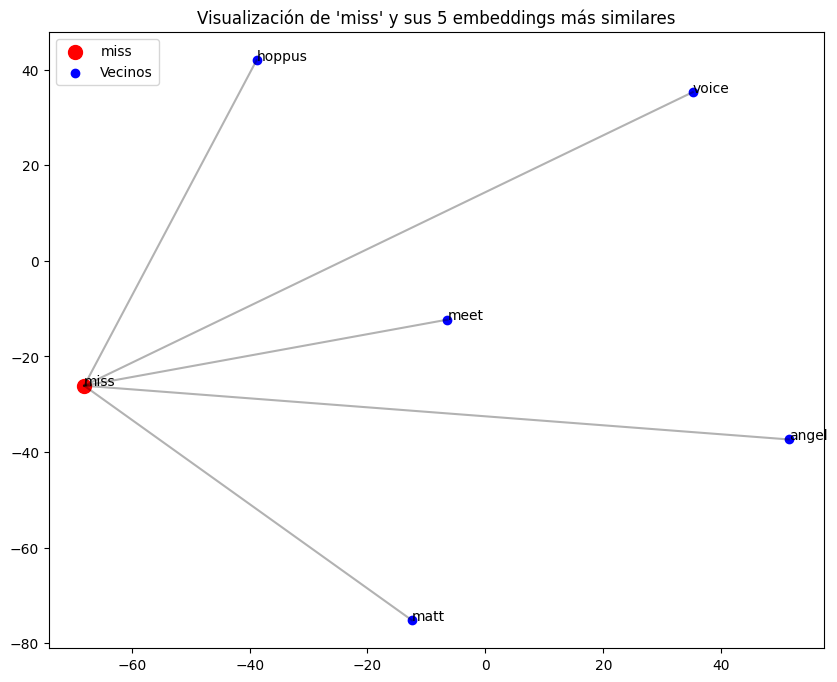

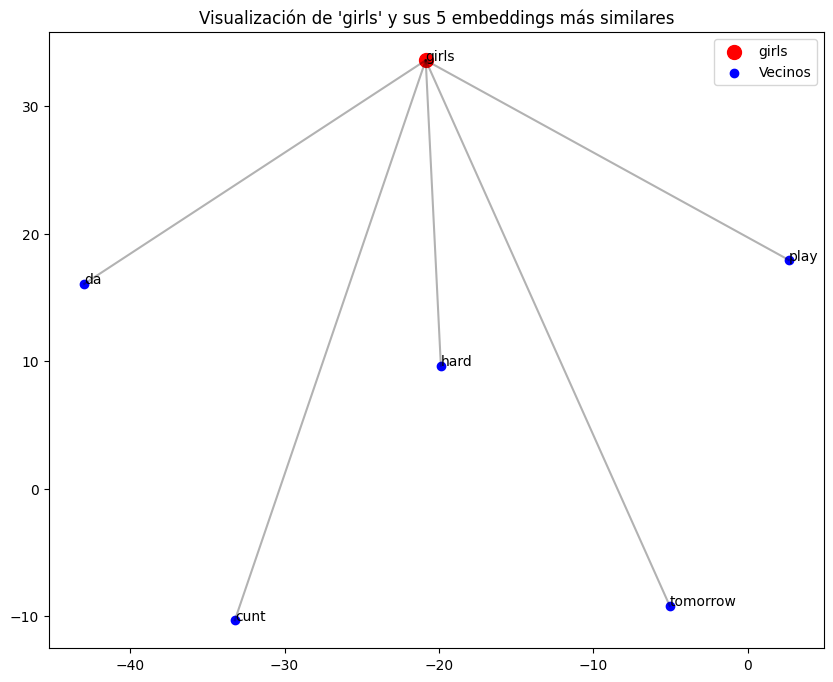

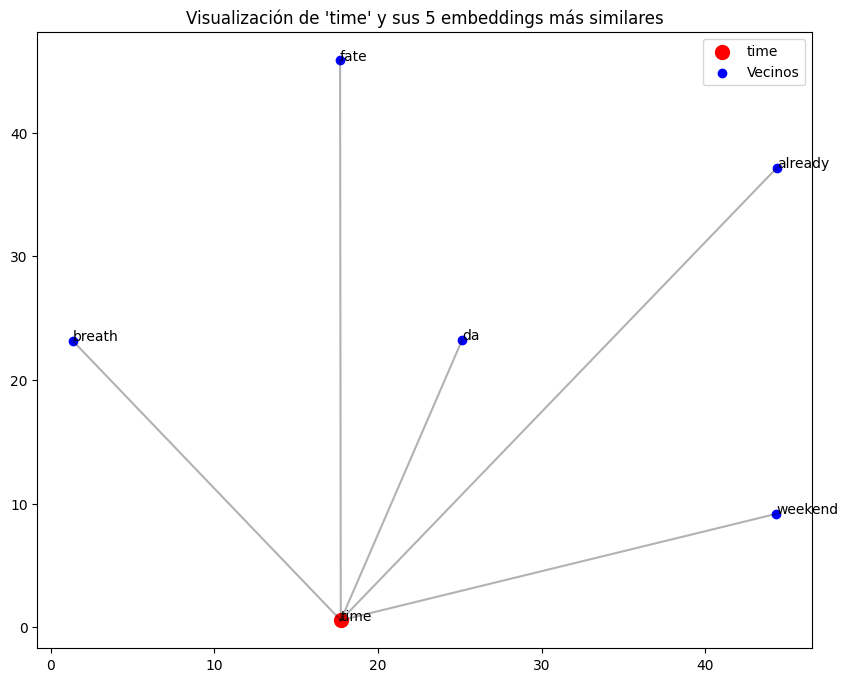

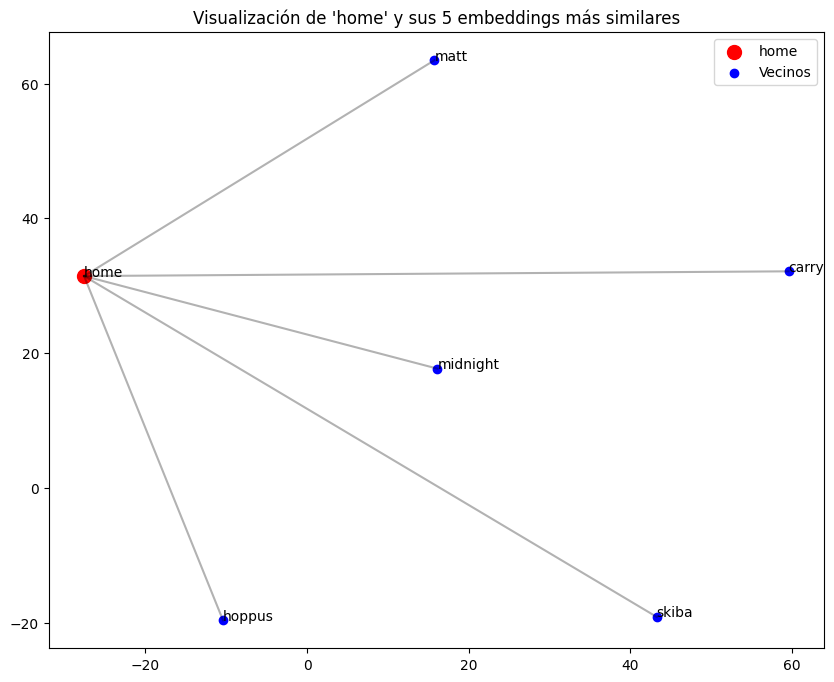

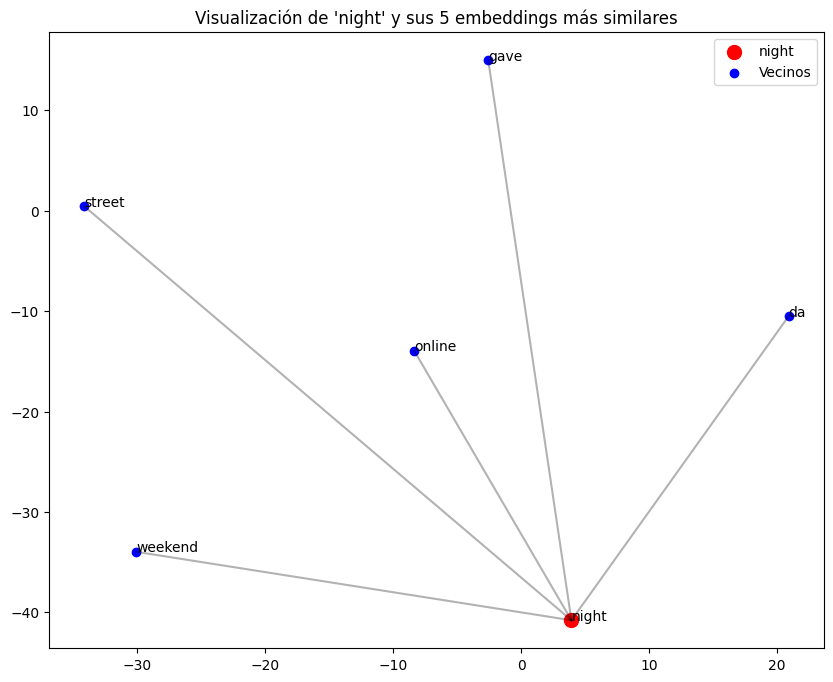

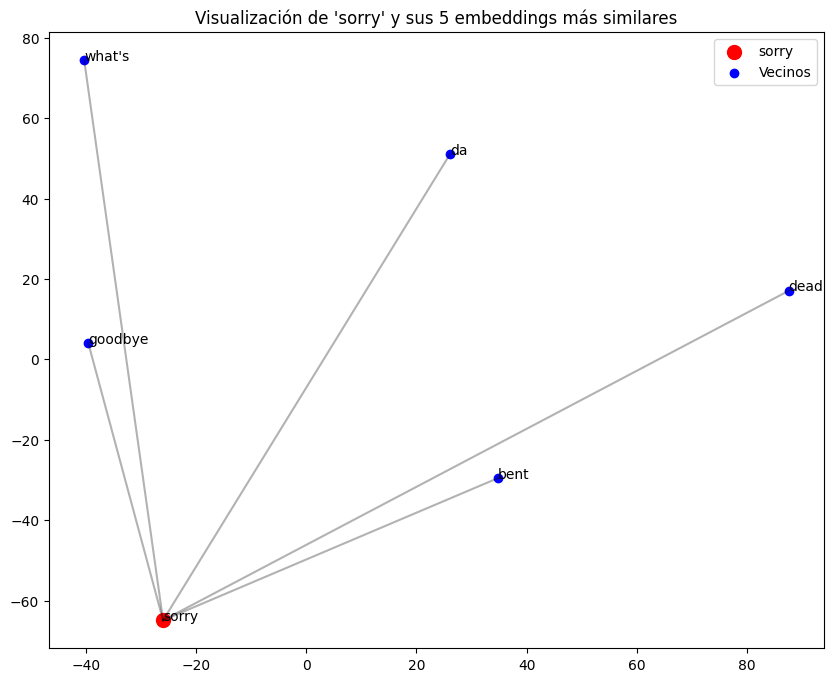

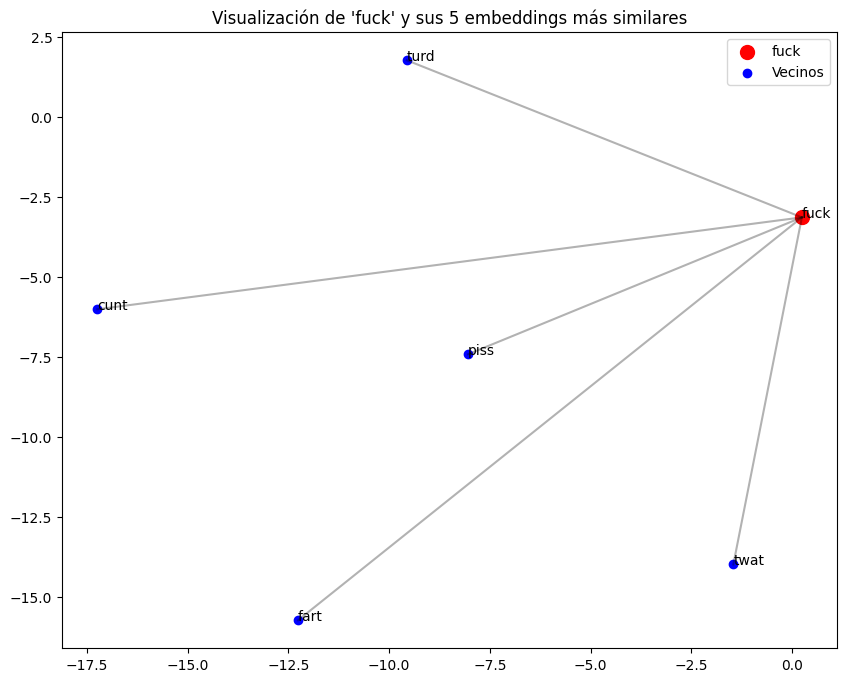

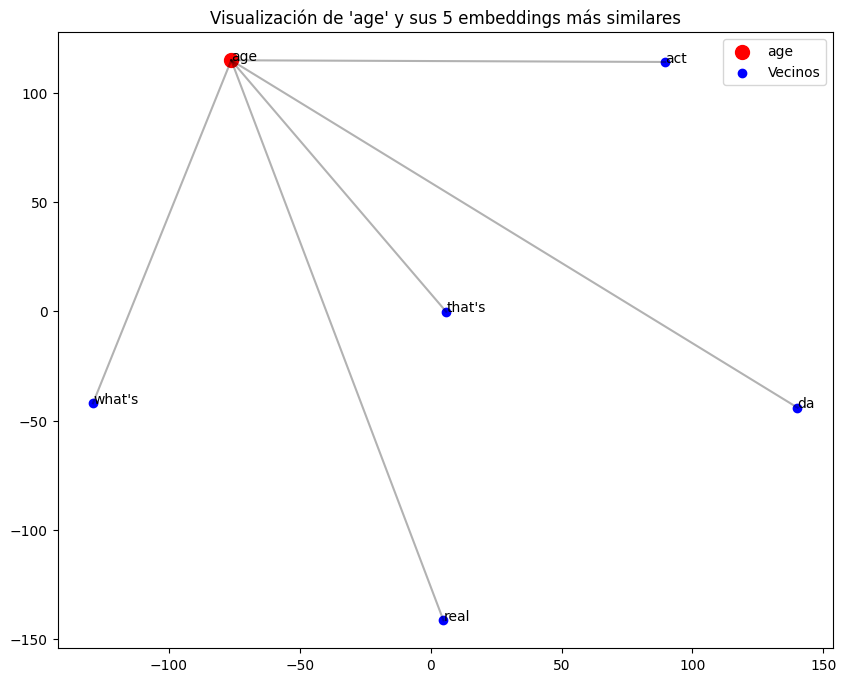

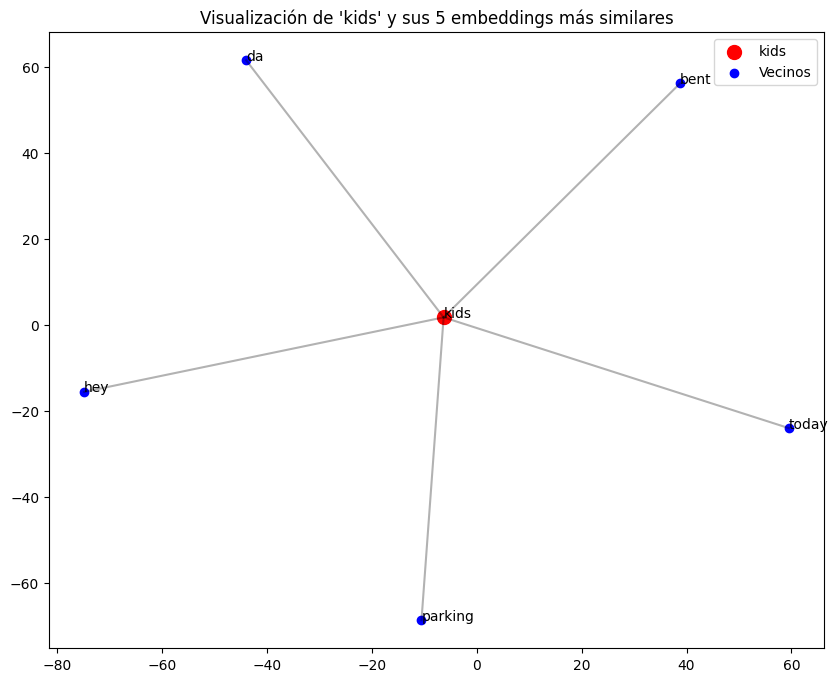

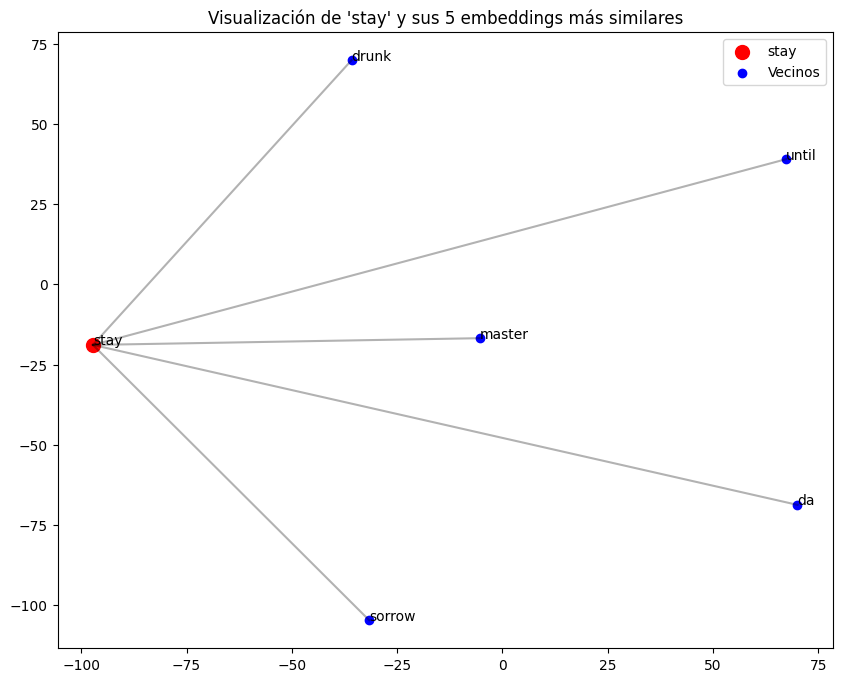

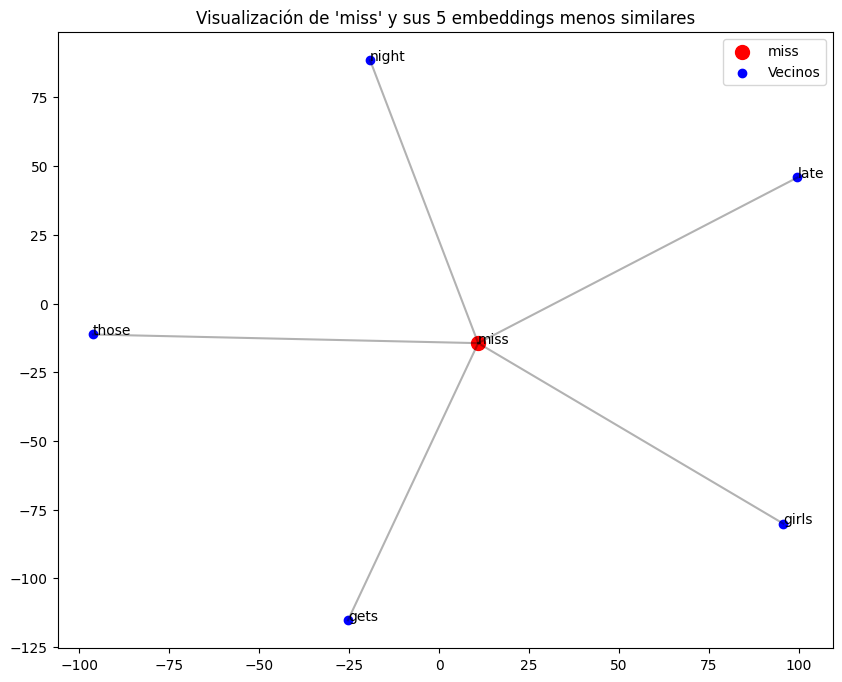

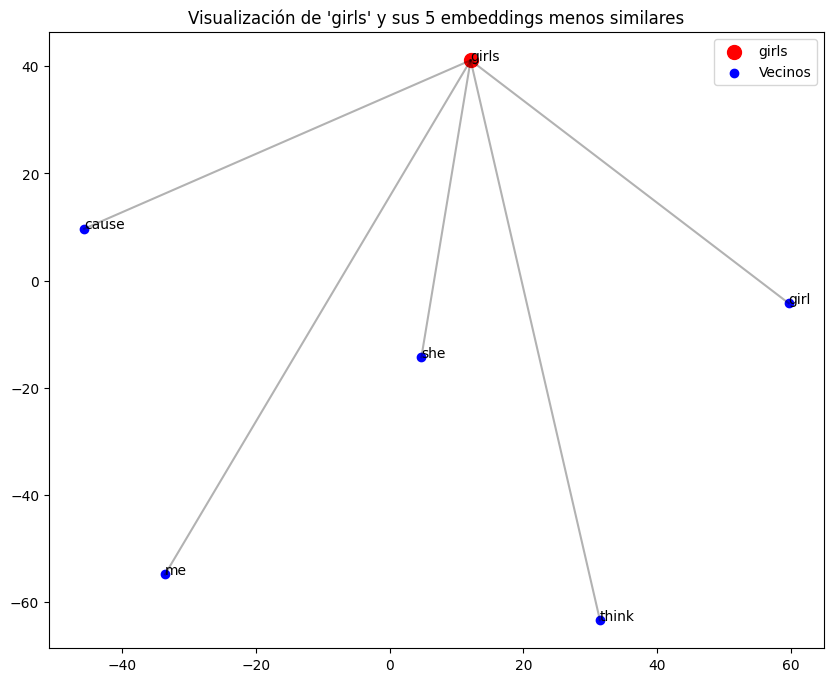

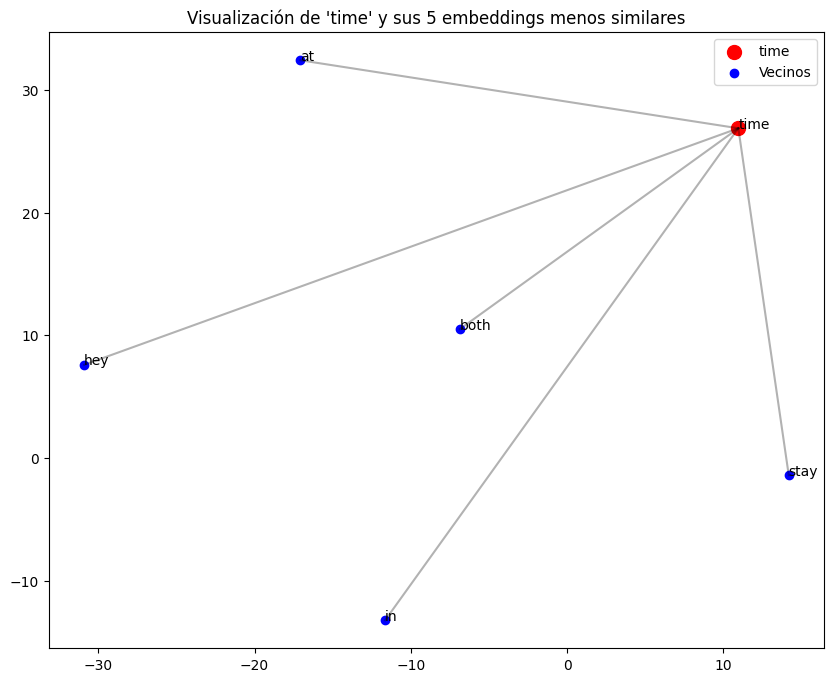

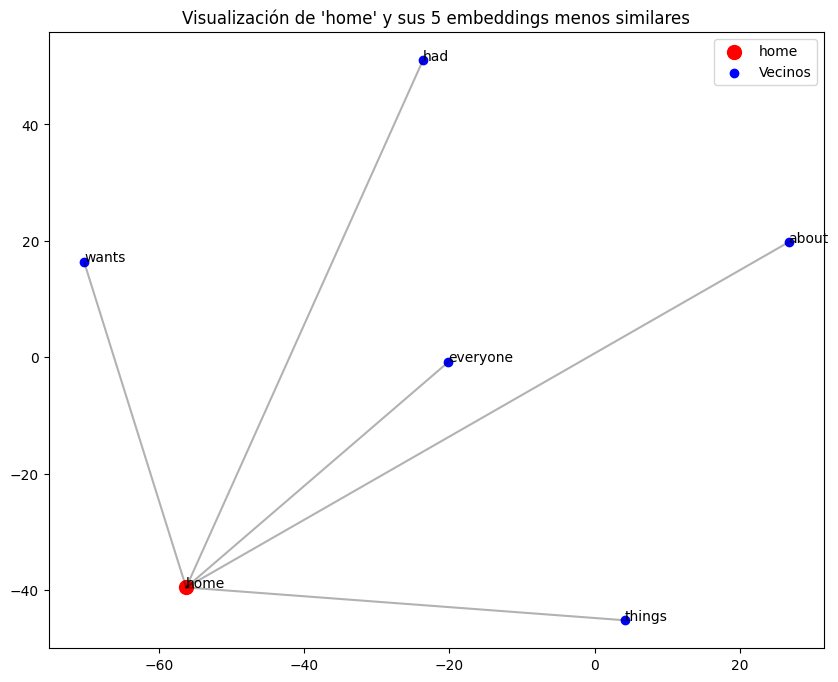

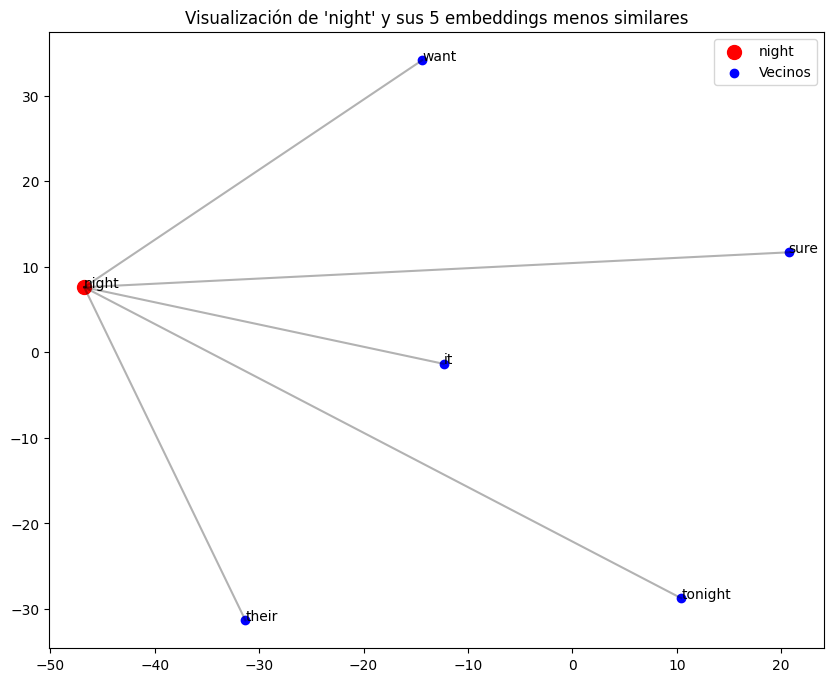

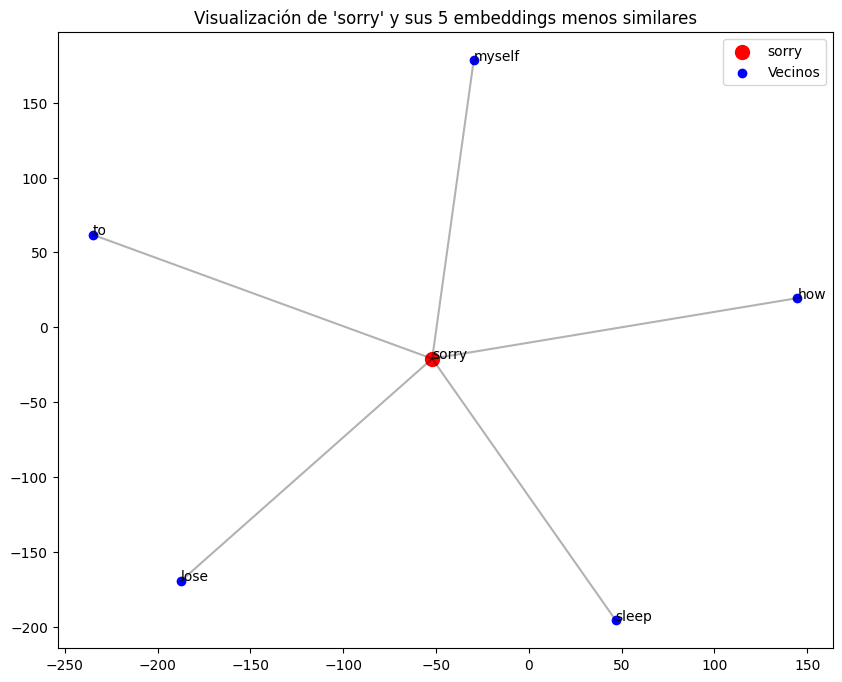

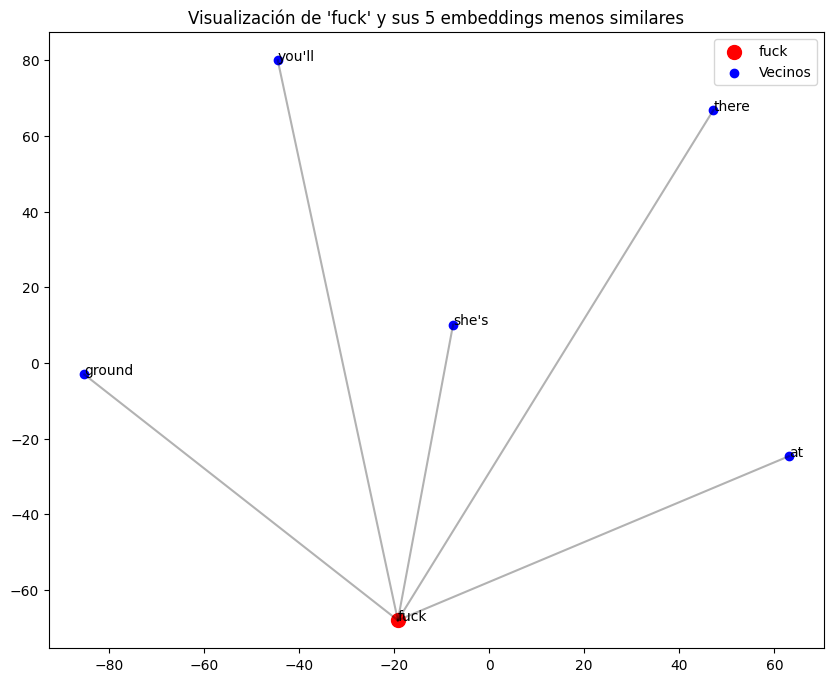

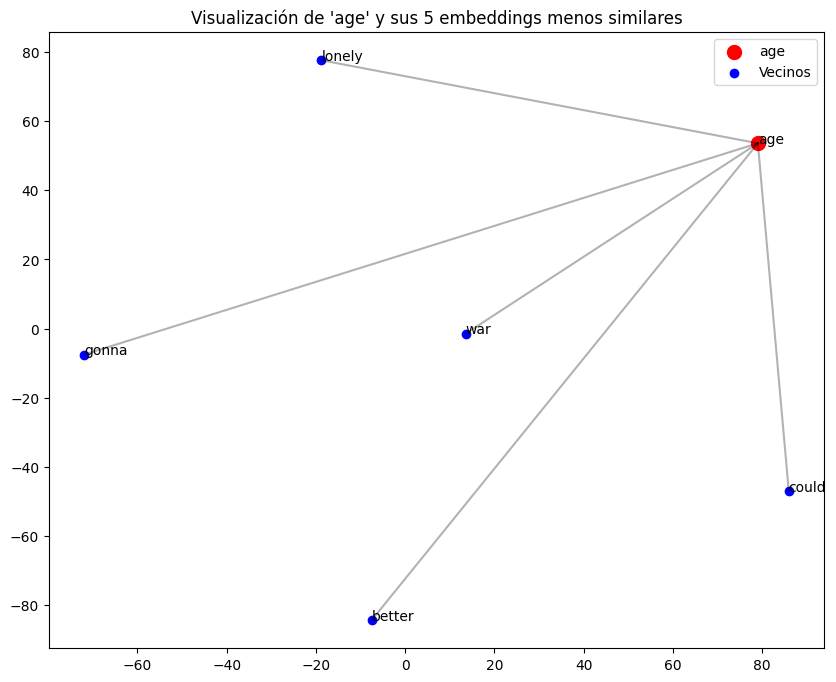

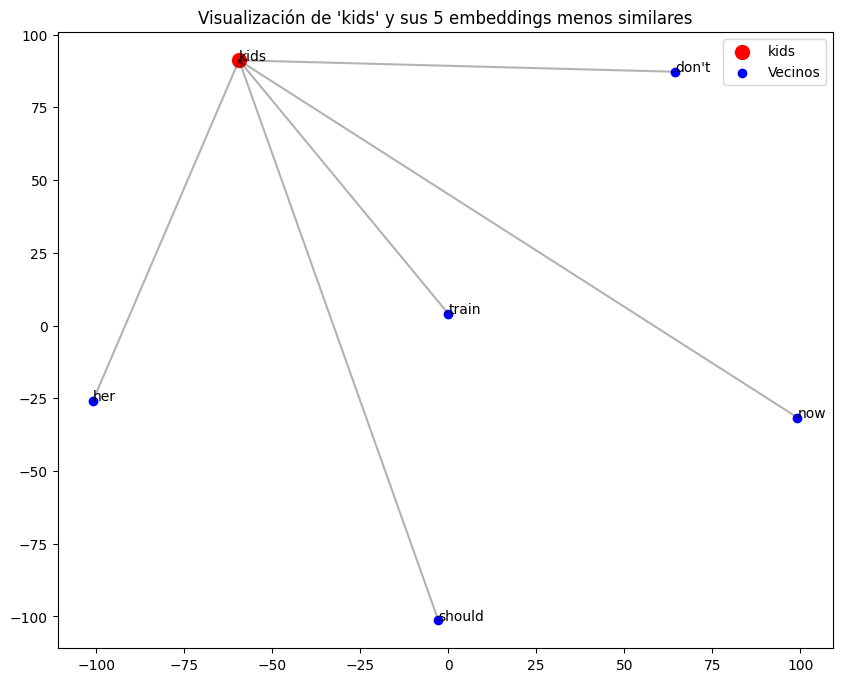

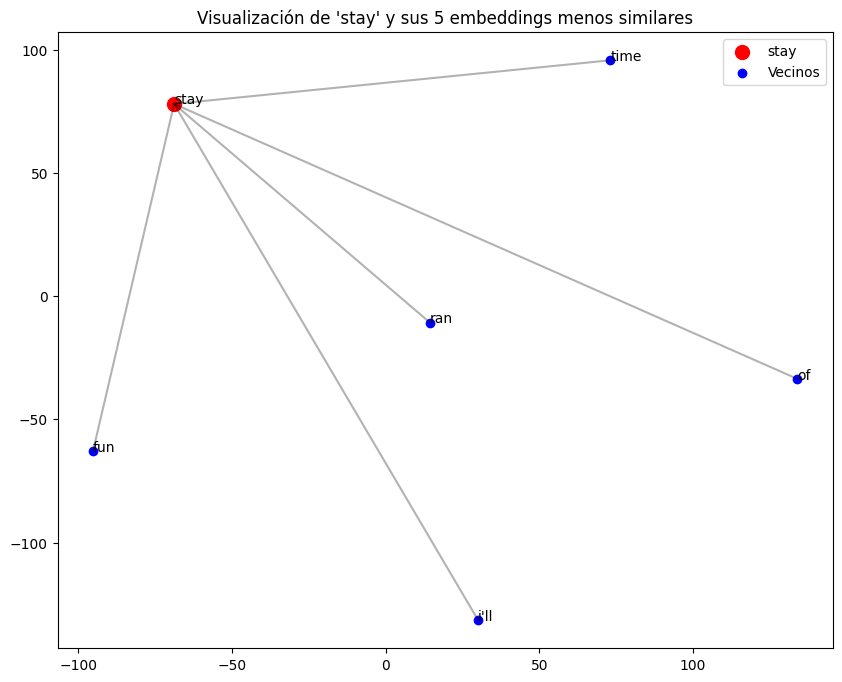

In [25]:
# Visualizar las más similares
for palabra in palabras_blink:
    reducir_y_graficar(w2v_model, palabra, similares=True)

# Visualizar las menos relacionadas
for palabra in palabras_blink:
    reducir_y_graficar(w2v_model, palabra, similares=False)


### Conclusión

Dado el rendimiento observado, se puede afirmar que el modelo logró captar correctamente las asociaciones temáticas y estilísticas dentro del universo lírico de Blink-182. Las palabras más similares muestran conexiones coherentes con temas recurrentes en sus canciones, como relaciones personales, rebeldía, adolescencia, tristeza o sarcasmo. Esto sugiere que los embeddings aprendieron bien el contexto en el que estas palabras suelen aparecer, permitiendo identificar núcleos semánticos característicos del grupo.

Por el contrario, las palabras menos relacionadas tienden a ser más genéricas o sin relación temática aparente, lo cual es esperable, ya que no comparten un contexto fuerte dentro del corpus. Esto también confirma que el modelo puede discriminar entre términos centrales y periféricos dentro de las letras.

Las conclusiones están influenciadas por el preprocesamiento realizado, la cantidad y calidad de letras analizadas, así como por la configuración del modelo Word2Vec. Una mejora futura podría consistir en organizar las letras por línea o verso como unidad semántica, para mejorar la coherencia del aprendizaje.

En resumen, el análisis demuestra que es posible capturar el estilo lírico de una banda a través de representaciones vectoriales de palabras, y que este tipo de modelos pueden ser útiles para estudiar la identidad lingüística de un artista o género musical.